In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# ── Config ─────────────────────────────────────────────────────────────────
DATA_PATH = "data/Dataset/Country-Wise Data/Ireland_dataset.csv"
FEATURES = [
    "Ammonia (mg/l)",
    "Biochemical Oxygen Demand (mg/l)",
    "Dissolved Oxygen (mg/l)",
    "Orthophosphate (mg/l)",
    "pH (ph units)",
    "Temperature (cel)",
    "Nitrogen (mg/l)",
    "Nitrate (mg/l)",
]
TARGET = "CCME_WQI"
RANDOM_SEED = 42
TEST_SIZE = 0.1
VAL_SIZE  = 0.1

In [5]:
# ── 1. Load data ────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df[TARGET].value_counts()}\n")

X = df[FEATURES].values
y_raw = df[TARGET].values

Dataset shape: (235019, 14)

Class distribution:
CCME_WQI
Excellent    197972
Good          33073
Fair           1629
Poor           1423
Marginal        922
Name: count, dtype: int64



In [8]:
# ── 2. Encode target ────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(y_raw)          # Excellent=0, Fair=1, Good=2, Marginal=3, Poor=4
num_classes = len(le.classes_)
print(f"Classes: {le.classes_}")

Classes: ['Excellent' 'Fair' 'Good' 'Marginal' 'Poor']


In [33]:
# ── 3. Train / test split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_train
)
print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

Train: 190365  Val: 21152  Test: 23502


In [34]:
# ── 4. Feature scaling ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [35]:
# ── 5. Class weights (handles imbalance) ────────────────────────────────────
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print(f"\nClass weights: { {le.classes_[k]: round(v, 2) for k, v in class_weights.items()} }\n")


Class weights: {'Excellent': np.float64(0.24), 'Fair': np.float64(28.87), 'Good': np.float64(1.42), 'Marginal': np.float64(50.97), 'Poor': np.float64(33.02)}



In [36]:
# ── 6. Build model ──────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(FEATURES),)),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,421 (48.52 KB)

 Trainable params: 12,037 (47.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [37]:
# ── 7. Callbacks ────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

In [38]:
# ── 8. Train ────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5581 - loss: 1.1173 - val_accuracy: 0.7529 - val_loss: 0.6505 - learning_rate: 0.0010
Epoch 2/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6674 - loss: 0.7034 - val_accuracy: 0.8275 - val_loss: 0.4700 - learning_rate: 0.0010
Epoch 3/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7364 - loss: 0.5682 - val_accuracy: 0.8875 - val_loss: 0.3348 - learning_rate: 0.0010
Epoch 4/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8058 - loss: 0.4708 - val_accuracy: 0.8746 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 5/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8443 - loss: 0.4139 - val_accuracy: 0.9548 - val_loss: 0.1446 - learning_rate: 0.0010
Epoch 6/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8722 - loss: 0.3710 - val_accuracy: 0.9606 - val_loss: 0.1154 - learning_rate: 0.0010
Epoch 7/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8935 - loss: 0.

In [39]:
# ── 9. Evaluate ─────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("F1-Score per class:")
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
for cls in le.classes_:
    print(f"{cls}: {report[cls]['f1-score']:.4f}")


Test accuracy: 0.9830  |  Test loss: 0.0454
735/735 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.99      1.00      0.99     19797
        Fair       0.56      0.98      0.71       163
        Good       0.97      0.91      0.94      3308
    Marginal       0.89      0.97      0.93        92
        Poor       1.00      0.94      0.97       142

    accuracy                           0.98     23502
   macro avg       0.88      0.96      0.91     23502
weighted avg       0.99      0.98      0.98     23502

Confusion Matrix:
[[19706     0    91     0     0]
 [    0   159     2     2     0]
 [  172   121  3015     0     0]
 [    0     3     0    89     0]
 [    0     0     0     9   133]]
F1-Score per class:
Excellent: 0.9934
Fair: 0.7130
Good: 0.9398
Marginal: 0.9271
Poor: 0.9673


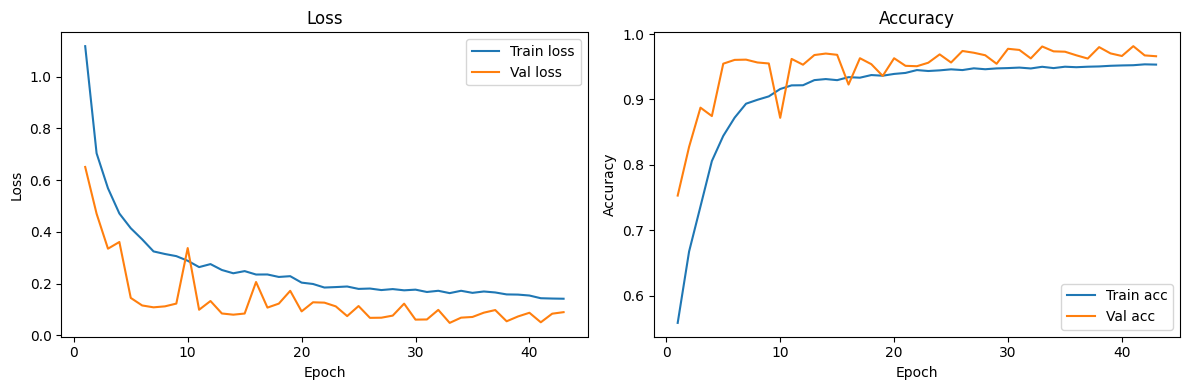

Plot saved to training_curves.png


In [40]:
# ── 10. Training curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_ran = range(1, len(history.history["loss"]) + 1)

ax1.plot(epochs_ran, history.history["loss"], label="Train loss")
ax1.plot(epochs_ran, history.history["val_loss"], label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_ran, history.history["accuracy"], label="Train acc")
ax2.plot(epochs_ran, history.history["val_accuracy"], label="Val acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Plot saved to training_curves.png")


In [42]:
import joblib

# ── 11. Save model + preprocessors ──────────────────────────────────────────
model.save("wqi_model.keras")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le,     "label_encoder.joblib")
print("Saved: wqi_model.keras | scaler.joblib | label_encoder.joblib")

Saved: wqi_model.keras | scaler.joblib | label_encoder.joblib


# Feature Ablation Study

We use a Random Forest to rank feature importances, then iteratively remove the least important feature and re-train to observe the impact on macro F1-score.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# ── Reload raw splits so we can index features freely ───────────────────────
df_ire = pd.read_csv(DATA_PATH)
X_raw = df_ire[FEATURES].values
y_raw_enc = le.transform(df_ire[TARGET].values)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw_enc, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_raw_enc
)
X_tr, X_v, y_tr, y_v = train_test_split(
    X_tr, y_tr, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_tr
)

scaler_abl = StandardScaler()
X_tr_s = scaler_abl.fit_transform(X_tr)
X_te_s  = scaler_abl.transform(X_te)

# ── Train RF on all 8 features to get importance ranking ────────────────────
rf_full = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_full.fit(X_tr_s, y_tr)

importances = rf_full.feature_importances_
feat_names  = np.array(FEATURES)

# Sort ascending — least important first (will be removed first)
sorted_idx = np.argsort(importances)
ranked_features = feat_names[sorted_idx]  # least → most important

print("Feature importance ranking (least → most important):")
for i, (name, imp) in enumerate(zip(ranked_features, importances[sorted_idx])):
    print(f"  {i+1}. {name:45s}  {imp:.4f}")

Feature importance ranking (least → most important):
  1. Nitrate (mg/l)                                 0.0044
  2. Nitrogen (mg/l)                                0.0100
  3. Temperature (cel)                              0.0108
  4. Dissolved Oxygen (mg/l)                        0.0331
  5. Biochemical Oxygen Demand (mg/l)               0.0378
  6. pH (ph units)                                  0.0696
  7. Ammonia (mg/l)                                 0.0811
  8. Orthophosphate (mg/l)                          0.7533


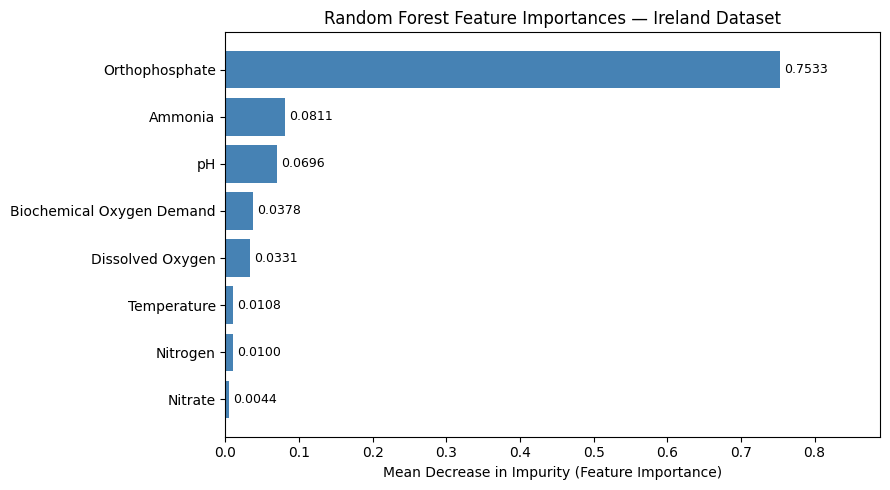

Saved to feature_importances.png


In [10]:
# ── Feature importance bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

short_names = [n.split(" (")[0] for n in ranked_features]  # strip units for readability
bars = ax.barh(short_names, importances[sorted_idx], color="steelblue")
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
ax.set_title("Random Forest Feature Importances — Ireland Dataset")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()
print("Saved to feature_importances.png")

In [11]:
# ── Ablation: remove least important feature one by one ─────────────────────
# Start with all 8 features; each iteration drops the next least important.
# We use RF (fast) to measure macro F1 at each step.

feature_indices = list(range(len(FEATURES)))   # 0..7 in original order
removal_order   = sorted_idx.tolist()           # least → most important (index into FEATURES)

results = []
active_indices = list(range(len(FEATURES)))     # start with all

for step in range(len(FEATURES)):
    col_idx = [feature_indices[i] for i in active_indices]
    X_tr_sub = X_tr_s[:, col_idx]
    X_te_sub = X_te_s[:, col_idx]

    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(X_tr_sub, y_tr)
    y_pred = rf.predict(X_te_sub)

    macro_f1 = f1_score(y_te, y_pred, average="macro")
    used_names = [FEATURES[i] for i in col_idx]
    removed    = FEATURES[removal_order[step - 1]] if step > 0 else "—"

    results.append({
        "n_features": len(active_indices),
        "removed":    removed,
        "macro_f1":   macro_f1,
        "features":   used_names,
    })
    print(f"n={len(active_indices):2d}  macro F1={macro_f1:.4f}  (just removed: {removed})")

    if active_indices:
        # Remove the least important remaining feature
        drop = removal_order[step]
        active_indices = [i for i in active_indices if i != drop]

results_df = pd.DataFrame(results)
print("\n", results_df[["n_features", "removed", "macro_f1"]].to_string(index=False))

n= 8  macro F1=0.9734  (just removed: —)
n= 7  macro F1=0.9800  (just removed: Nitrate (mg/l))
n= 6  macro F1=0.9848  (just removed: Nitrogen (mg/l))
n= 5  macro F1=0.9866  (just removed: Temperature (cel))
n= 4  macro F1=0.9750  (just removed: Dissolved Oxygen (mg/l))
n= 3  macro F1=0.9571  (just removed: Biochemical Oxygen Demand (mg/l))
n= 2  macro F1=0.9315  (just removed: pH (ph units))
n= 1  macro F1=0.8440  (just removed: Ammonia (mg/l))

  n_features                          removed  macro_f1
          8                                —  0.973370
          7                   Nitrate (mg/l)  0.979971
          6                  Nitrogen (mg/l)  0.984766
          5                Temperature (cel)  0.986577
          4          Dissolved Oxygen (mg/l)  0.974954
          3 Biochemical Oxygen Demand (mg/l)  0.957067
          2                    pH (ph units)  0.931455
          1                   Ammonia (mg/l)  0.843954


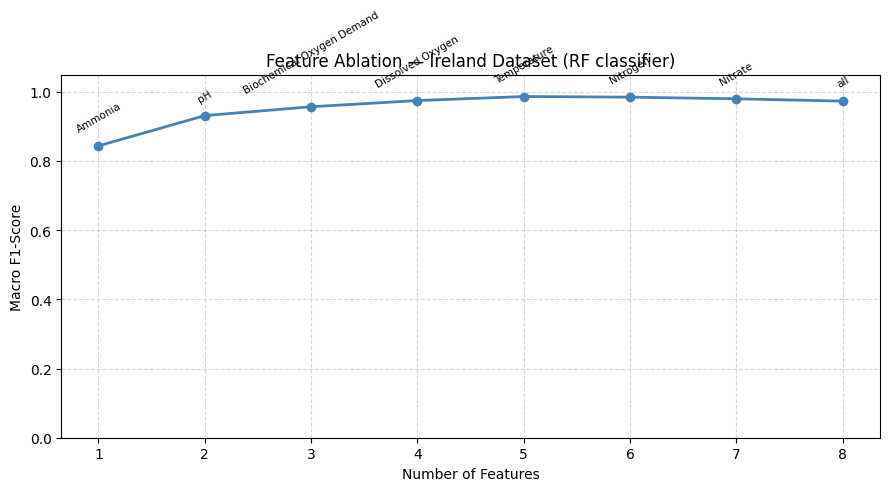

Saved to ablation_curve.png


In [13]:
# ── Ablation curve plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(results_df["n_features"], results_df["macro_f1"], marker="o", linewidth=2, color="steelblue")
ax.set_xlabel("Number of Features")
ax.set_ylabel("Macro F1-Score")
ax.set_title("Feature Ablation — Ireland Dataset (RF classifier)")
ax.set_xticks(results_df["n_features"])
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)

# Annotate each point with the feature that was just removed
for _, row in results_df.iterrows():
    label = row["removed"].split(" (")[0] if row["removed"] != "—" else "all"
    ax.annotate(
        label,
        xy=(row["n_features"], row["macro_f1"]),
        xytext=(0, 10), textcoords="offset points",
        ha="center", fontsize=7.5, rotation=30,
    )

plt.tight_layout()
plt.savefig("ablation_curve.png", dpi=150)
plt.show()
print("Saved to ablation_curve.png")

## Permutation Importance vs. MDI

Permutation importance measures how much macro F1 drops when a single feature's values are randomly shuffled on the **test set**. Unlike MDI, it is evaluated on held-out data and is not biased toward high-cardinality features.

In [12]:
from sklearn.inspection import permutation_importance

# Use the RF trained on all 8 features
perm = permutation_importance(
    rf_full, X_te_s, y_te,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

perm_means = perm.importances_mean
perm_stds  = perm.importances_std

print("Permutation importance (mean drop in macro F1):")
perm_order = np.argsort(perm_means)
for i in perm_order:
    print(f"  {FEATURES[i]:45s}  {perm_means[i]:.4f} +/- {perm_stds[i]:.4f}")

Permutation importance (mean drop in macro F1):
  Nitrogen (mg/l)                                -0.0034 +/- 0.0011
  Nitrate (mg/l)                                 0.0030 +/- 0.0041
  Temperature (cel)                              0.0123 +/- 0.0014
  Dissolved Oxygen (mg/l)                        0.0131 +/- 0.0016
  Biochemical Oxygen Demand (mg/l)               0.0264 +/- 0.0021
  pH (ph units)                                  0.0318 +/- 0.0023
  Ammonia (mg/l)                                 0.1144 +/- 0.0018
  Orthophosphate (mg/l)                          0.7016 +/- 0.0044


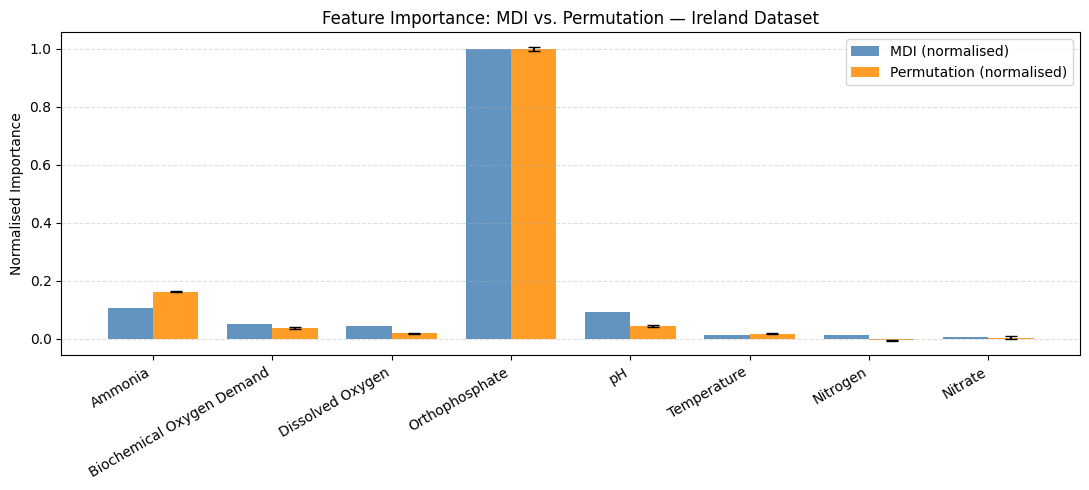

Saved to importance_comparison.png


In [13]:
# ── Side-by-side comparison plot ─────────────────────────────────────────────
short = [n.split(" (")[0] for n in feat_names]  # strip units

# Normalise both to [0,1] for fair visual comparison
mdi_norm  = importances / importances.max()
perm_norm = perm_means  / perm_means.max() if perm_means.max() > 0 else perm_means

x = np.arange(len(FEATURES))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, mdi_norm,  width, label="MDI (normalised)",        color="steelblue",  alpha=0.85)
ax.bar(x + width/2, perm_norm, width, label="Permutation (normalised)", color="darkorange", alpha=0.85,
       yerr=perm_stds / perm_means.max(), capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(short, rotation=30, ha="right")
ax.set_ylabel("Normalised Importance")
ax.set_title("Feature Importance: MDI vs. Permutation — Ireland Dataset")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("importance_comparison.png", dpi=150)
plt.show()
print("Saved to importance_comparison.png")